In [6]:
import torch
import matplotlib.pyplot as plt

device = torch.device("cuda:0")
dtype = torch.float

In [7]:
# We're going to try to find the coefficients (a, b, c) for a quaratic polynomial y = ax^2 + bx +c where 
# the true values are a = 2.0, b = 7.0, and c= -8.0 in the range of x = [-5, 2]

# Hyperameters
lr = 1e-6
epochs = 3000
initial_loss = 1.

x = torch.linspace(-5, 2, 1000, device=device, dtype=dtype)
y_truth = 2.0 * x ** 2 + 7.0 * x - 8.0

In [8]:


# Initialize random values for the coefficients
a = torch.randn((), device=device, dtype=dtype, requires_grad=True)
b = torch.randn((), device=device, dtype=dtype, requires_grad=True)
c = torch.randn((), device=device, dtype=dtype, requires_grad=True)


for e in range(epochs):
    y_pred0 = a * x**2 + b*x + c

    loss = (y_pred0 - y_truth).pow(2).sum()

    if e == 0:
        initial_loss = loss.item()
    if e % 99 == 0:
        print(f"Ieration: {e} Loss(e)/Loss(0): {loss.item()/initial_loss}")
    
    loss.backward()

    with torch.no_grad():
        a -= lr * a.grad
        b -= lr * b.grad
        c -= lr * c.grad
        

        a.grad = None 
        b.grad = None
        c.grad = None
     



Ieration: 0 Loss(e)/Loss(0): 1.0
Ieration: 99 Loss(e)/Loss(0): 0.30362816026472905
Ieration: 198 Loss(e)/Loss(0): 0.21881587633912136
Ieration: 297 Loss(e)/Loss(0): 0.1591523508276896
Ieration: 396 Loss(e)/Loss(0): 0.11683619433738557
Ieration: 495 Loss(e)/Loss(0): 0.08656266645826179
Ieration: 594 Loss(e)/Loss(0): 0.0647083355613461
Ieration: 693 Loss(e)/Loss(0): 0.04878547007041891
Ieration: 792 Loss(e)/Loss(0): 0.03707606728024424
Ieration: 891 Loss(e)/Loss(0): 0.028386108502122438
Ieration: 990 Loss(e)/Loss(0): 0.021879524579779652
Ieration: 1089 Loss(e)/Loss(0): 0.016966527460857243
Ieration: 1188 Loss(e)/Loss(0): 0.013227412561853061
Ieration: 1287 Loss(e)/Loss(0): 0.010360952288434764
Ieration: 1386 Loss(e)/Loss(0): 0.008148915199863029
Ieration: 1485 Loss(e)/Loss(0): 0.0064318022268901945
Ieration: 1584 Loss(e)/Loss(0): 0.005091854894380626
Ieration: 1683 Loss(e)/Loss(0): 0.004041450641815498
Ieration: 1782 Loss(e)/Loss(0): 0.0032147304527388363
Ieration: 1881 Loss(e)/Loss(0): 

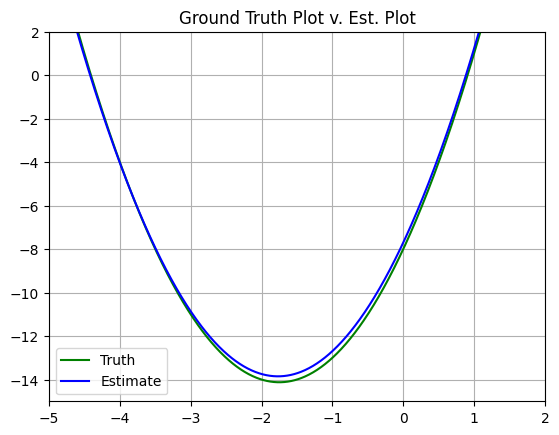

In [9]:
y_pred_plot0 = a.item() * x**2 + b.item()*x + c.item()

plt.plot(x.cpu().numpy(), y_truth.cpu().numpy(), color='g', label='Truth')
plt.plot(x.cpu().numpy(), y_pred_plot0.cpu().numpy(), color='b', label='Estimate')
plt.xlim(-5, 2)
plt.ylim(-15, 2)
plt.grid(True)
plt.legend()
plt.title('Ground Truth Plot v. Est. Plot')


plt.show()

In [ ]:
p = torch.tensor([1, 2], device=device)
xx = x.unsqueeze(-1).pow(p)

model = torch.nn.Sequential(
    torch.nn.Linear(2, 1),
    torch.nn.Flatten(0, 1)
).to(device)

loss_fn = torch.nn.MSELoss(reduction='sum')

for e in range(epochs):
    y_pred1 = model(xx)

    loss = loss_fn(y_pred1, y_truth)

    if e % 99 == 0:
        print(f"Iteration: {e} Loss: {loss.item()}")

    model.zero_grad()

    loss.backward()

    with torch.no_grad():
        for param in model.parameters():
            param -= lr * param.grad

linear_layer = model[0]

print(f" Result = y = {linear_layer.bias.item()} + {linear_layer.weight[:, 0].item()} x + {linear_layer.weight[:, 1].item()} x^2")


Iteration: 0 Loss: 98014.4609375
Iteration: 99 Loss: 65227.3671875
Iteration: 198 Loss: 48320.7421875
Iteration: 297 Loss: 36117.3125
Iteration: 396 Loss: 27227.0234375
Iteration: 495 Loss: 20690.056640625
Iteration: 594 Loss: 15839.2587890625
Iteration: 693 Loss: 12207.6494140625
Iteration: 792 Loss: 9465.7578125
Iteration: 891 Loss: 7379.212890625
Iteration: 990 Loss: 5779.76513671875
Iteration: 1089 Loss: 4545.58544921875
Iteration: 1188 Loss: 3587.605224609375
Iteration: 1287 Loss: 2840.1044921875
Iteration: 1386 Loss: 2254.1435546875
Iteration: 1485 Loss: 1792.989990234375
Iteration: 1584 Loss: 1428.8060302734375
Iteration: 1683 Loss: 1140.35400390625
Iteration: 1782 Loss: 911.3126220703125
Iteration: 1881 Loss: 729.0635986328125
Iteration: 1980 Loss: 583.7871704101562
Iteration: 2079 Loss: 467.80908203125
Iteration: 2178 Loss: 375.10736083984375
Iteration: 2277 Loss: 300.929931640625
Iteration: 2376 Loss: 241.523681640625
Iteration: 2475 Loss: 193.9129638671875
Iteration: 2574 Lo

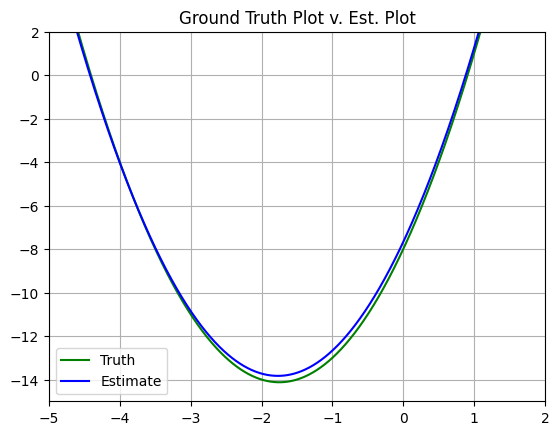

In [11]:
y_pred_plot1 = linear_layer.weight[:, 1].item() * x**2 + linear_layer.weight[:, 0].item()*x + linear_layer.bias.item()

plt.plot(x.cpu().numpy(), y_truth.cpu().numpy(), color='g', label='Truth')
plt.plot(x.cpu().numpy(), y_pred_plot1.cpu().numpy(), color='b', label='Estimate')
plt.xlim(-5, 2)
plt.ylim(-15, 2)
plt.grid(True)
plt.legend()
plt.title('Ground Truth Plot v. Est. Plot')


plt.show()

In [13]:
optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)

for e  in range(epochs):
    y_pred2 = model(xx)

    loss = loss_fn(y_pred2,y_truth)

    if e % 99 == 0:
        print(f"Iteration: {e} || Loss: {loss.item()}")
    
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

linear_layer = model[0]

print(f" Result = y = {linear_layer.bias.item()} + {linear_layer.weight[:, 0].item()} x + {linear_layer.weight[:, 1].item()} x^2")

Iteration: 0 || Loss: 60.760833740234375
Iteration: 99 || Loss: 60.671234130859375
Iteration: 198 || Loss: 60.6258430480957
Iteration: 297 || Loss: 60.585601806640625
Iteration: 396 || Loss: 60.54570388793945
Iteration: 495 || Loss: 60.50562286376953
Iteration: 594 || Loss: 60.465824127197266
Iteration: 693 || Loss: 60.425926208496094
Iteration: 792 || Loss: 60.38616943359375
Iteration: 891 || Loss: 60.34621047973633
Iteration: 990 || Loss: 60.306541442871094
Iteration: 1089 || Loss: 60.26675796508789
Iteration: 1188 || Loss: 60.22711944580078
Iteration: 1287 || Loss: 60.18729019165039
Iteration: 1386 || Loss: 60.14772033691406
Iteration: 1485 || Loss: 60.108055114746094
Iteration: 1584 || Loss: 60.06844711303711
Iteration: 1683 || Loss: 60.02880859375
Iteration: 1782 || Loss: 59.989349365234375
Iteration: 1881 || Loss: 59.94981384277344
Iteration: 1980 || Loss: 59.910396575927734
Iteration: 2079 || Loss: 59.870792388916016
Iteration: 2178 || Loss: 59.83144760131836
Iteration: 2277 || 

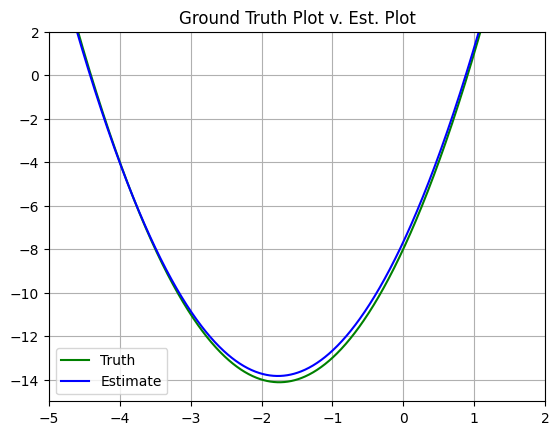

In [14]:
y_pred_plot2 = linear_layer.weight[:, 1].item() * x**2 + linear_layer.weight[:, 0].item()*x + linear_layer.bias.item()

plt.plot(x.cpu().numpy(), y_truth.cpu().numpy(), color='g', label='Truth')
plt.plot(x.cpu().numpy(), y_pred_plot2.cpu().numpy(), color='b', label='Estimate')
plt.xlim(-5, 2)
plt.ylim(-15, 2)
plt.grid(True)
plt.legend()
plt.title('Ground Truth Plot v. Est. Plot')


plt.show()